In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df_sample = pd.read_csv("adv_sample_150000.csv")

In [3]:
df_sample.shape

(150000, 90)

In [4]:
df_sample["label"].value_counts()

label
BENIGN            50000
DoS_ATTACK        50000
NON_DoS_ATTACK    50000
Name: count, dtype: int64

In [5]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # 0.2
)

In [7]:
X_min_raw = X.min(axis=0).values
X_max_raw = X.max(axis=0).values
X_min_df = pd.DataFrame([X_min_raw], columns=X.columns)
X_max_df = pd.DataFrame([X_max_raw], columns=X.columns)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_full = scaler.transform(X)
X_min_scaled = scaler.transform(X_min_df).flatten()
X_max_scaled = scaler.transform(X_max_df).flatten()
# X_min_scaled = scaler.transform(X_min_raw.reshape(1, -1)).flatten()
# X_max_scaled = scaler.transform(X_max_raw.reshape(1, -1)).flatten()
x_min_t = torch.tensor(X_min_scaled, dtype=torch.float32, device=device)
x_max_t = torch.tensor(X_max_scaled, dtype=torch.float32, device=device)

In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=2048, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=2048)
X_full_tensor = torch.tensor(X_full, dtype=torch.float32)
y_full_tensor = torch.tensor(y.values, dtype=torch.long)

In [9]:
input_size = 88
hidden_size = 128
num_classes = 3

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), #256
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [10]:
model = MultiClassDNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [11]:
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 0.5907, Val Loss: 0.3949
Epoch 2, Train Loss: 0.3836, Val Loss: 0.3728
Epoch 3, Train Loss: 0.3732, Val Loss: 0.3689
Epoch 4, Train Loss: 0.3699, Val Loss: 0.3660
Epoch 5, Train Loss: 0.3678, Val Loss: 0.3648
Epoch 6, Train Loss: 0.3659, Val Loss: 0.3640
Epoch 7, Train Loss: 0.3649, Val Loss: 0.3635
Epoch 8, Train Loss: 0.3641, Val Loss: 0.3624
Epoch 9, Train Loss: 0.3630, Val Loss: 0.3618
Epoch 10, Train Loss: 0.3627, Val Loss: 0.3617
Epoch 11, Train Loss: 0.3621, Val Loss: 0.3610
Epoch 12, Train Loss: 0.3614, Val Loss: 0.3604
Epoch 13, Train Loss: 0.3610, Val Loss: 0.3607
Epoch 14, Train Loss: 0.3609, Val Loss: 0.3599
Epoch 15, Train Loss: 0.3603, Val Loss: 0.3605
Epoch 16, Train Loss: 0.3605, Val Loss: 0.3594
Epoch 17, Train Loss: 0.3600, Val Loss: 0.3600
Epoch 18, Train Loss: 0.3598, Val Loss: 0.3593
Epoch 19, Train Loss: 0.3595, Val Loss: 0.3597
Epoch 20, Train Loss: 0.3593, Val Loss: 0.3590
Epoch 21, Train Loss: 0.3593, Val Loss: 0.3592
Epoch 22, Train Loss: 

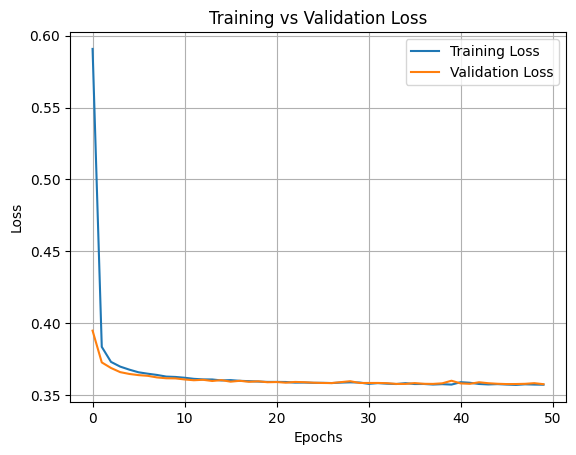

In [12]:
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [13]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

In [14]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8890444444444444
Weighted F1: 0.888970583689098
Macro F1: 0.888970583689098
ROC-AUC: 0.9716410388888889


In [15]:
print(classification_report(y, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     15000
    DoS_ATTACK       0.82      0.85      0.84     15000
NON_DoS_ATTACK       0.85      0.81      0.83     15000

      accuracy                           0.89     45000
     macro avg       0.89      0.89      0.89     45000
  weighted avg       0.89      0.89      0.89     45000



In [ ]:
def pgd_attack(model, ae_X, ae_y, feature_cols, n_samples=5000, strategy="zeroth_order", noise_scale=0.05, step_size=0.02, random_state=42):
    rng = np.random.default_rng(random_state)
    preds = model.predict(ae_X.astype("float32"))
    correct_mask = preds == ae_y
    ae_X_correct = ae_X[correct_mask].reset_index(drop=True)
    ae_y_correct = ae_y[correct_mask]
    print(f"Eligible samples (correctly classified): {correct_mask.sum()}")
    crafted_rows, true_labels, pred_labels = [], [], []
    for i in range(min(n_samples, len(ae_X_correct))):
        row = ae_X_correct.iloc[i]
        true_label = ae_y_correct[i]
        if strategy == "random":
            X_adv, label = blackbox_boundary_search(
                model, row, feature_cols, true_label,
                noise_scale=noise_scale, random_state=rng.integers(1e9))
        else:
            X_adv, label = zeroth_order_boundary(
                model, row, feature_cols, true_label,
                step_size=step_size, random_state=rng.integers(1e9))
        if X_adv is None:
            continue 
        crafted_rows.append(X_adv)
        true_labels.append(label)
        pred_labels.append(
            model.predict(pd.DataFrame([X_adv], columns=feature_cols))[0])
    print(f"Successfully crafted: {len(crafted_rows)} / {min(n_samples, len(ae_X_correct))}")
    result_df = pd.DataFrame(crafted_rows, columns=feature_cols)
    result_df["true_label"] = true_labels
    result_df["y_pred"] = pred_labels
    return result_df

In [17]:
def epsilon_eval(model, X_full_tensor, y_full_tensor, epsilon, verbose=True, x_min=None, x_max=None):
    x_adv = pgd_attack(model, X_full_tensor, y_full_tensor, epsilon=epsilon, x_min=x_min, x_max=x_max, verbose=verbose)
    model.eval()
    with torch.no_grad():
        clean_logits = model(X_full_tensor.to(device))
        y_pred_clean = torch.argmax(clean_logits, dim=1).cpu().numpy()
        logits = model(x_adv.to(device))
        y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    y_true = y_full_tensor.cpu().numpy()
    correct_clean = (y_pred_clean == y_true)
    successful_attacks = ((y_pred != y_true) & correct_clean)
    asr = (successful_attacks.sum() / max(correct_clean.sum(), 1))  
    x_adv_np = x_adv.cpu().numpy()
    adv_df = pd.DataFrame(scaler.inverse_transform(x_adv_np), columns=X.columns).round(0).astype(int)
    adv_df["true_label"] = y_true
    adv_df["y_pred"] = y_pred
    success_mask = y_pred != y_true
    adv_df = adv_df[success_mask]
    filename = "adversarial_epsilon_" + str(epsilon) + ".csv"
    adv_df.to_csv(filename, index=False)
    clean_acc = accuracy_score(y_true, y_pred_clean)
    adv_acc = accuracy_score(y_true, y_pred)
    print("=== ADVERSARIAL EVALUATION ===")
    print(f"Epsilon : {epsilon}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred))
    return {"epsilon": epsilon, "clean_accuracy": clean_acc, "adv_accuracy": adv_acc, "asr": asr}

In [18]:
results = []
for epsilon in [0.01, 0.05, 0.1, 0.5]:
    results.append(epsilon_eval(model, X_full_tensor, y_full_tensor, epsilon, verbose=True, x_min=x_min_t, x_max=x_max_t))

  Restart 1/5 | α=0.0003 | loss=CE | fool_rate=0.127 | cumulative_fool=0.127
  Restart 2/5 | α=0.0003 | loss=CW | fool_rate=0.125 | cumulative_fool=0.128
  Restart 3/5 | α=0.0003 | loss=CE | fool_rate=0.127 | cumulative_fool=0.128
  Restart 4/5 | α=0.0003 | loss=CW | fool_rate=0.125 | cumulative_fool=0.128
  Restart 5/5 | α=0.0003 | loss=CE | fool_rate=0.127 | cumulative_fool=0.128
=== ADVERSARIAL EVALUATION ===
Epsilon : 0.01
Accuracy: 0.8725
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     50000
           1       0.82      0.84      0.83     50000
           2       0.80      0.82      0.81     50000

    accuracy                           0.87    150000
   macro avg       0.88      0.87      0.87    150000
weighted avg       0.88      0.87      0.87    150000

  Restart 1/5 | α=0.0015 | loss=CE | fool_rate=0.127 | cumulative_fool=0.127
  Restart 2/5 | α=0.0015 | loss=CW | fool_rate=0.125 | cumulative_fool=0.127
  Restart 3/5 | α

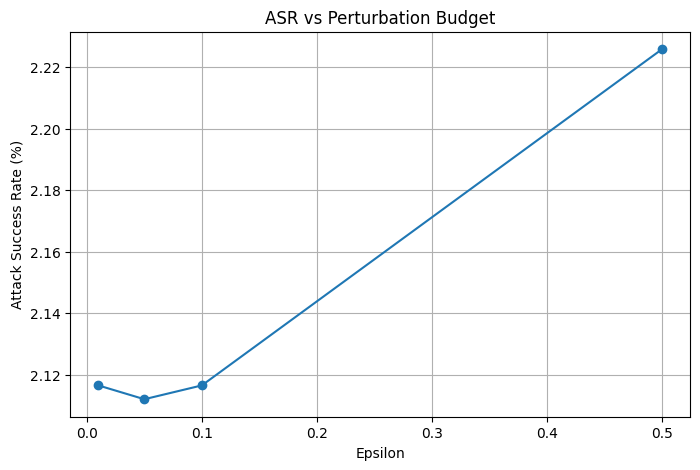

In [19]:
eps = [r["epsilon"] for r in results]
asr = [r["asr"] * 100 for r in results]

plt.figure(figsize=(8,5))
plt.plot(eps, asr, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
plt.title("ASR vs Perturbation Budget")
plt.grid(True)
plt.show()